**LOAN DEFAULT PREDICTION SYSTEM**

In [41]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score
sns.set_style('whitegrid')

In [42]:
import pandas as pd
#Load the Loan Default Prediction Data
df=pd.read_csv('/content/Loan_default.csv', on_bad_lines='skip', low_memory=False)

In [43]:
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56.0,85994.0,50587.0,520.0,80.0,4.0,15.23,36.0,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0.0
1,HPSK72WA7R,69.0,50432.0,124440.0,458.0,15.0,1.0,4.81,60.0,0.68,Master's,Full-time,Married,No,No,Other,Yes,0.0
2,C1OZ6DPJ8Y,46.0,84208.0,129188.0,451.0,26.0,3.0,21.17,24.0,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1.0
3,V2KKSFM3UN,32.0,31713.0,44799.0,743.0,0.0,3.0,7.07,24.0,0.23,High School,Full-time,Married,No,No,Business,No,0.0
4,EY08JDHTZP,60.0,20437.0,9139.0,633.0,8.0,4.0,6.51,48.0,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0.0


In [44]:
df.shape

(10780, 18)

In [45]:
df.isnull().sum().sum()

np.int64(17)

In [46]:
df.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,10779.000000,10779.000000,10779.000000,10779.000000,10779.000000,10779.000000,10779.000000,10779.000000,10779.000000,10779.000000
mean,43.540681,82932.641525,127822.158363,574.813062,58.520085,2.498284,13.432374,36.125800,0.503318,0.118193
std,14.903241,39155.168051,70531.435181,157.835972,34.356398,1.120778,6.648199,16.993306,0.230483,0.322851
min,18.000000,15000.000000,5005.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,49116.000000,66886.500000,439.000000,29.000000,1.000000,7.615000,24.000000,0.300000,0.000000
50%,43.000000,82959.000000,127397.000000,576.000000,59.000000,2.000000,13.500000,36.000000,0.510000,0.000000
75%,56.000000,116853.500000,188957.000000,709.000000,88.000000,4.000000,19.120000,48.000000,0.700000,0.000000
max,69.000000,149997.000000,249950.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


In [47]:
import pandas as pd
df=pd.read_csv('/content/Loan_default.csv', on_bad_lines='skip', low_memory=False)
print(df.isnull().sum())

LoanID            0
Age               1
Income            1
LoanAmount        1
CreditScore       1
MonthsEmployed    1
NumCreditLines    1
InterestRate      1
LoanTerm          1
DTIRatio          1
Education         1
EmploymentType    1
MaritalStatus     1
HasMortgage       1
HasDependents     1
LoanPurpose       1
HasCoSigner       1
Default           1
dtype: int64


Default rate: 11.8%


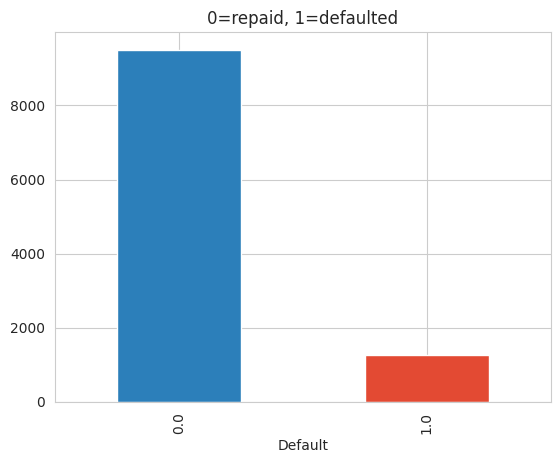

In [48]:
#NOTE: Only 12% default. The data is imbalanced keep an eye on it not just as accuracy.
#Target balance-What % actually default?
import matplotlib.pyplot as plt
rate=df['Default'].mean()
print(f'Default rate: {rate:.1%}')
df['Default'].value_counts().plot(kind='bar', color=['#2c7fba','#e34a33'])
plt.title('0=repaid, 1=defaulted')
plt.show()

In [49]:
print(df['Default'].value_counts(dropna=False))

Default
0.0    9505
1.0    1274
NaN       1
Name: count, dtype: int64


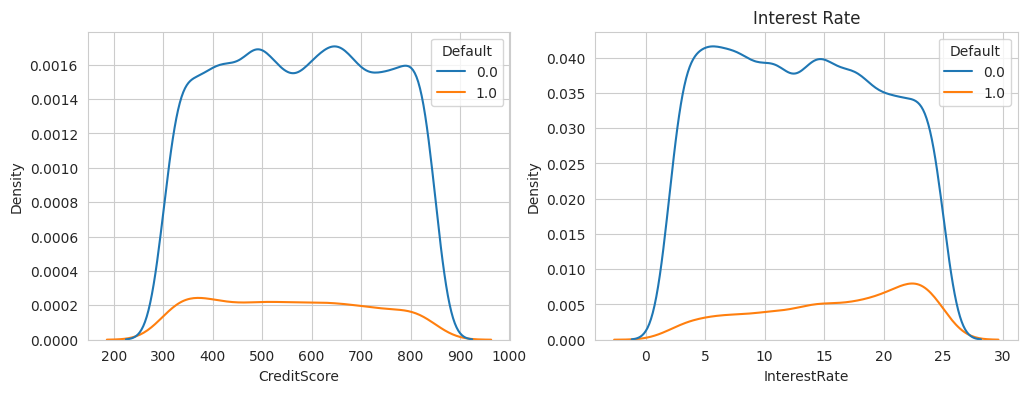

In [50]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
#For there credit score and Interest rate
df['CreditScore'] = pd.to_numeric(df['CreditScore'], errors='coerce')
df['InterestRate'] = pd.to_numeric(df['InterestRate'], errors='coerce')
fig, ax =plt.subplots(1,2, figsize=(12,4))
sns.kdeplot(data=df, x='CreditScore', hue='Default', ax=ax[0])
sns.kdeplot(data=df, x='InterestRate', hue='Default', ax=ax[1])
ax[1].set_title('Interest Rate')
plt.show()

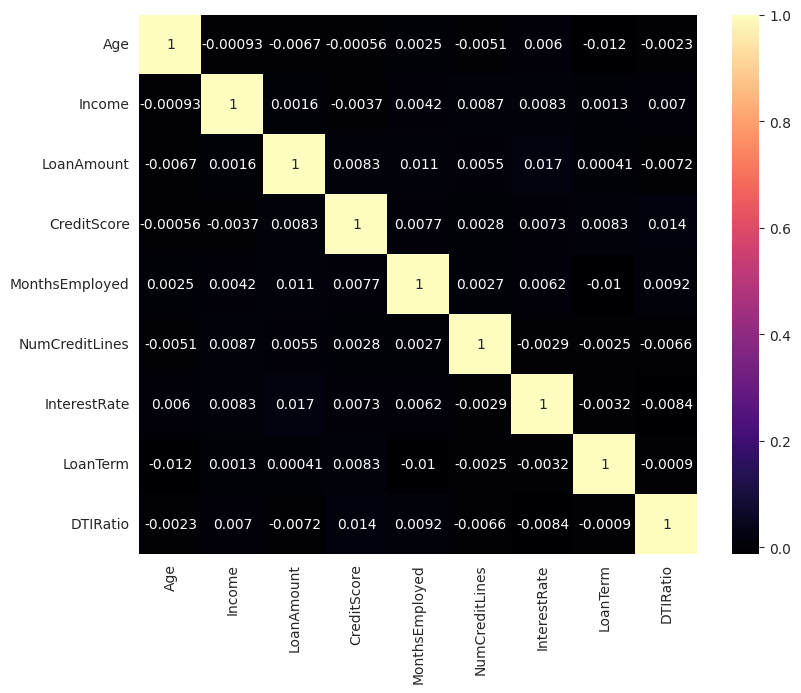

In [51]:
#The Correlation
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

num=['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio']

# Ensure all columns in 'num' are numeric, coercing errors
for col in num:
    df[col] = pd.to_numeric(df[col], errors='coerce')

plt.figure(figsize=(9,7))
sns.heatmap(df[num].select_dtypes(include=np.number).corr(), annot=True, cmap='magma')
plt.show()

**ONE HOT ENCODING**

In [52]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Reload the dataframe to ensure a clean state after a potential crash
df = pd.read_csv('/content/Loan_default.csv', on_bad_lines='skip', low_memory=False)

# Drop 'LoanID' as it's a unique identifier and not useful for encoding or modeling
df = df.drop(columns=['LoanID'])

# Perform one-hot encoding on the remaining categorical columns
df_encoded = pd.get_dummies(df, drop_first=True)

x = df_encoded.drop(columns=['Default'])
y = df_encoded['Default']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print('X_train shape:', x_train.shape, 'X_test shape:', x_test.shape)

X_train shape: (8624, 24) X_test shape: (2156, 24)


In [53]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the DataFrame df
df = pd.read_csv('/content/Loan_default.csv', on_bad_lines='skip', low_memory=False)

# Perform one-hot encoding
df = df.drop(columns=["LoanID"])
df_enc = pd.get_dummies(df, drop_first=True)
x = df_enc.drop(columns=['Default'])
y = df_enc['Default']
print(x.columns.tolist())

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42)
print('train:', x_train.shape, 'test:', x_test.shape)

['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education_High School', "Education_Master's", 'Education_PhD', 'EmploymentType_Part-time', 'EmploymentType_Self-employed', 'EmploymentType_Unemployed', 'MaritalStatus_Married', 'MaritalStatus_Single', 'HasMortgage_Yes', 'HasDependents_Yes', 'LoanPurpose_Business', 'LoanPurpose_Education', 'LoanPurpose_Home', 'LoanPurpose_Other', 'HasCoSigner_Yes']
train: (8624, 24) test: (2156, 24)


**Model Building**

**Logistic Regression**

In [54]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

# Ensure df is prepared correctly before splitting
# Reload the dataframe to ensure a clean state (as done in previous preprocessing cells)
df_current = pd.read_csv('/content/Loan_default.csv', on_bad_lines='skip', low_memory=False)

# Drop 'LoanID' as it's a unique identifier and not useful for encoding or modeling
df_current = df_current.drop(columns=['LoanID'])

# Perform one-hot encoding on the remaining categorical columns
df_encoded = pd.get_dummies(df_current, drop_first=True)

# Drop rows with any NaN values from the encoded DataFrame
df_encoded.dropna(inplace=True)

# Define features (x) and target (y)
x = df_encoded.drop(columns=['Default'])
y = df_encoded['Default']

# Split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# train a logistic Regression Model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' is good for small data
log_reg_model.fit(x_train, y_train)

#Make predictions on the test set
y_pred = log_reg_model.predict(x_test)

#Evaluate the model
accuracy_log_reg = accuracy_score(y_test, y_pred)
f1_log_reg = f1_score(y_test, y_pred)

print(f'Logistic Regression Accuracy: {accuracy_log_reg:.4f}')
print(f'Logistic Regression F1 Score: {f1_log_reg:.4f}')

Logistic Regression Accuracy: 0.8724
Logistic Regression F1 Score: 0.0000


**Logistic Regression Feature Importance**

In [55]:
import pandas as pd

# Check if the model has the coef_ attribute
if hasattr(log_reg_model, 'coef_'):
    feature_importance = pd.DataFrame({
        'Feature': x_train.columns,
        'Importance': log_reg_model.coef_[0]
        })
    feature_importance['absolute importance'] = abs(feature_importance['Importance'])
    feature_importance = feature_importance.sort_values(by='absolute importance', ascending=False)
    print(feature_importance.head(10))
else:
    print("Error: The 'log_reg_model' does not have a 'coef_' attribute. This might indicate that the Logistic Regression model was not fitted correctly or encountered an issue during training. Please review the model training step.")
    print("The F1 score of 0.0000 in the previous cell also suggests the model might not be learning the minority class, which could be related to this issue.")

                      Feature  Importance  absolute importance
0                         Age   -0.026533             0.026533
6                InterestRate    0.008827             0.008827
4              MonthsEmployed   -0.007866             0.007866
7                    LoanTerm   -0.002745             0.002745
3                 CreditScore   -0.000751             0.000751
23            HasCoSigner_Yes   -0.000306             0.000306
18          HasDependents_Yes   -0.000274             0.000274
14  EmploymentType_Unemployed    0.000198             0.000198
15      MaritalStatus_Married   -0.000186             0.000186
10         Education_Master's   -0.000150             0.000150


**Random Forest**

In [56]:
#Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

rf_model = RandomForestClassifier(n_estimators=200,
                                  max_depth=10,
                                  random_state=42)
rf_model.fit(x_train, y_train)
y_pred = rf_model.predict(x_test)
accuracy_rf = accuracy_score(y_test, y_pred)
f1_rf = f1_score(y_test, y_pred)

#Evaluate the model
print(f'Random Forest Accuracy: {accuracy_rf:.4f}')
print(f'Random Forest F1 Score: {f1_rf:.4f}')

Random Forest Accuracy: 0.8729
Random Forest F1 Score: 0.0072


In [57]:
#Feature Importance
feature_importance_rf = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': rf_model.feature_importances_
    }).sort_values(
        by='Importance',
        ascending=False
        )

feature_importance_rf

,Feature,Importance
6,InterestRate,0.137316
0,Age,0.135869
1,Income,0.127699
2,LoanAmount,0.107451
3,CreditScore,0.096667
4,MonthsEmployed,0.093953
8,DTIRatio,0.077555
7,LoanTerm,0.032042
5,NumCreditLines,0.026889
23,HasCoSigner_Yes,0.013625


**XGBOOST**

In [58]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=10,
    random_state=42
)
xgb_model.fit(x_train, y_train)
y_pred = xgb_model.predict(x_test)
accuracy_xgb = accuracy_score(y_test, y_pred)
f1_xgb = f1_score(y_test, y_pred)

#Evaluate the model
print(f'XGBoost Accuracy: {accuracy_xgb:.4f}')
print(f'XGBoost F1 Score: {f1_xgb:.4f}')

XGBoost Accuracy: 0.8729
XGBoost F1 Score: 0.1491


**XGBOOST Feature Importance**

In [59]:
feature_importance_xgb = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': xgb_model.feature_importances_
    }).sort_values(
        by='Importance',
        ascending=False
        )

feature_importance_xgb

,Feature,Importance
0,Age,0.064782
6,InterestRate,0.052271
23,HasCoSigner_Yes,0.047736
14,EmploymentType_Unemployed,0.045708
1,Income,0.045409
2,LoanAmount,0.044735
18,HasDependents_Yes,0.044640
9,Education_High School,0.044316
4,MonthsEmployed,0.043309
3,CreditScore,0.041792


**Compare All These Three Models**

In [60]:
#Comparing all the three models
comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost'
      ],
    'Accuracy': [
        accuracy_log_reg,
        accuracy_rf,
        accuracy_xgb
      ],
    'F1 Score': [
        f1_log_reg,
        f1_rf,
        f1_xgb
      ]
    })
comparison.sort_values(
    by='F1 Score',
    ascending=False)

,Model,Accuracy,F1 Score
2,XGBoost,0.872913,0.149068
1,Random Forest,0.872913,0.007246
0,Logistic Regression,0.872449,0.000000


**Visualize the Models**

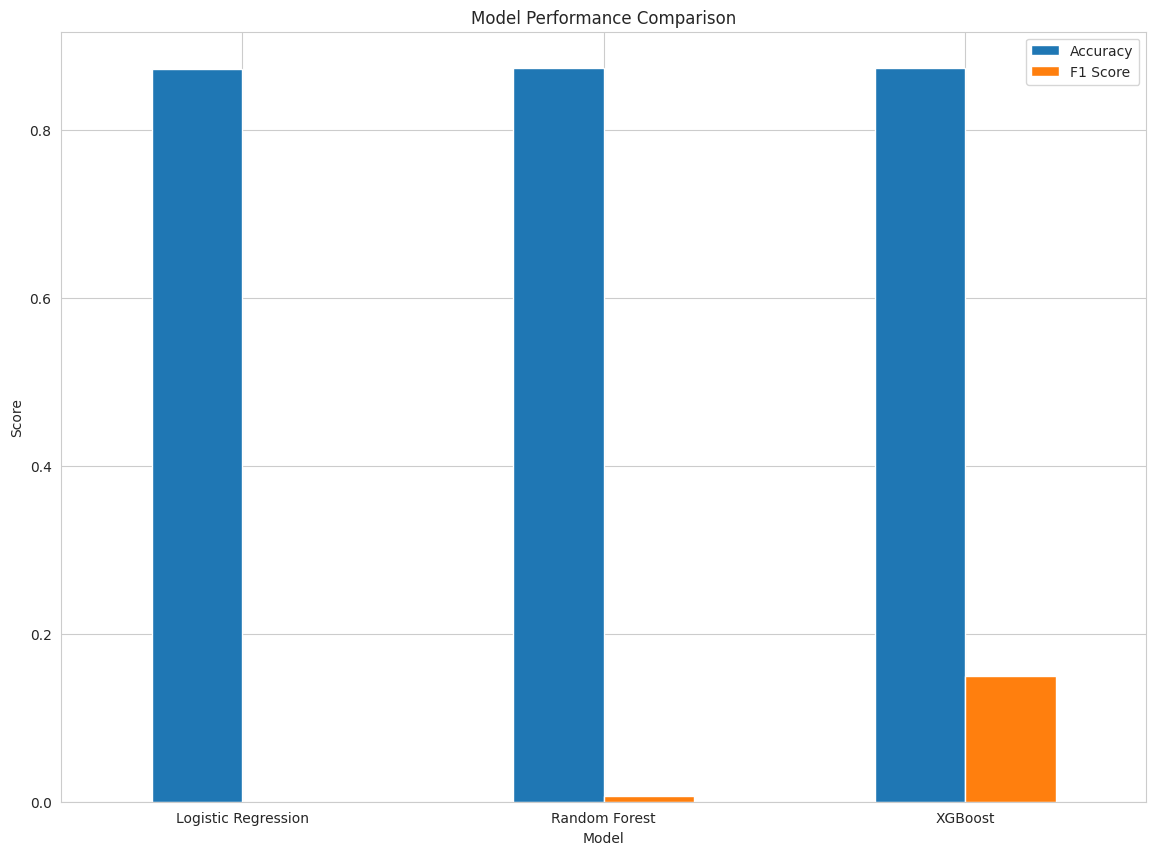

In [61]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score

# --- Start: Ensure all necessary variables are defined ---

# Load the dataframe
df_current = pd.read_csv('/content/Loan_default.csv', on_bad_lines='skip', low_memory=False)

# Drop 'LoanID'
df_current = df_current.drop(columns=['LoanID'])

# Perform one-hot encoding
df_encoded = pd.get_dummies(df_current, drop_first=True)

# Drop rows with any NaN values from the encoded DataFrame
df_encoded.dropna(inplace=True)

# Define features (x) and target (y)
x = df_encoded.drop(columns=['Default'])
y = df_encoded['Default']

# Split the data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# 1. Logistic Regression Model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear')
log_reg_model.fit(x_train, y_train)
y_pred_log_reg = log_reg_model.predict(x_test)
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
f1_log_reg = f1_score(y_test, y_pred_log_reg)

# 2. Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf_model.fit(x_train, y_train)
y_pred_rf = rf_model.predict(x_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

# 3. XGBoost Classifier
xgb_model = XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=10, random_state=42)
xgb_model.fit(x_train, y_train)
y_pred_xgb = xgb_model.predict(x_test)
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

# --- End: Ensure all necessary variables are defined ---

# Re-create the comparison DataFrame to ensure it's defined
comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost'
      ],
    'Accuracy': [
        accuracy_log_reg,
        accuracy_rf,
        accuracy_xgb
      ],
    'F1 Score': [
        f1_log_reg,
        f1_rf,
        f1_xgb
      ]
    })

# comparison set
comparison.set_index('Model')[['Accuracy', 'F1 Score']].plot(
    kind='bar',
    figsize=(14,10)
    )

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

**Select the best Model Automatically**

In [62]:
best_model_name = comparison.sort_values(
    by='F1 Score',
    ascending=False
    ).iloc[0]['Model']

print(f"best Model: {best_model_name}")

best Model: XGBoost


**Save Model**

In [63]:
import joblib
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score

# --- Start: Ensure all necessary variables are defined ---

# Load the dataframe
df_current = pd.read_csv('/content/Loan_default.csv', on_bad_lines='skip', low_memory=False)

# Drop 'LoanID'
df_current = df_current.drop(columns=['LoanID'])

# Perform one-hot encoding
df_encoded = pd.get_dummies(df_current, drop_first=True)

# Drop rows where the 'Default' column has NaN values
df_encoded.dropna(subset=['Default'], inplace=True)

# Define features (x) and target (y)
x = df_encoded.drop(columns=['Default'])
y = df_encoded['Default']

# Split the data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# 1. Logistic Regression Model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear')
log_reg_model.fit(x_train, y_train)
y_pred_log_reg = log_reg_model.predict(x_test)
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
f1_log_reg = f1_score(y_test, y_pred_log_reg)

# 2. Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf_model.fit(x_train, y_train)
y_pred_rf = rf_model.predict(x_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

# 3. XGBoost Classifier
xgb_model = XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=10, random_state=42)
xgb_model.fit(x_train, y_train)
y_pred_xgb = xgb_model.predict(x_test)
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

# --- End: Ensure all necessary variables are defined ---

# Re-create the comparison DataFrame to ensure it's defined and the variables are in scope
comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost'
      ],
    'Accuracy': [
        accuracy_log_reg,
        accuracy_rf,
        accuracy_xgb
      ],
    'F1 Score': [
        f1_log_reg,
        f1_rf,
        f1_xgb
      ]
    })

best_model_name = comparison.sort_values(
    by='F1 Score',
    ascending=False
    ).iloc[0]['Model']

if best_model_name == 'Logistic Regression':
  best_model = log_reg_model
elif best_model_name == 'Random Forest':
  best_model = rf_model
else:
  best_model = xgb_model

joblib.dump(best_model, 'loan_default_model.pkl')
print("Best model saved successfully!")

Best model saved successfully!


In [64]:
print('--- Currently Installed Package Versions in Colab ---')
!pip show pandas joblib scikit-learn xgboost numpy streamlit matplotlib seaborn

print('''
To resolve the `EOFError` in Streamlit, you need to update your `requirements.txt` (cell `oIvhVHJ1XqJ4`) to explicitly include these exact versions (e.g., `pandas==X.Y.Z`).

After updating `requirements.txt`:
1. Re-run cell `oIvhVHJ1XqJ4` to generate the new `requirements.txt`.
2. Re-run cell `KCjApm7N3Z1x` to ensure the model is saved with the correct library versions.
3. Re-deploy your Streamlit application, making sure the updated `requirements.txt` is used for dependency installation.''')

--- Currently Installed Package Versions in Colab ---
Name: pandas
Version: 2.2.2
Summary: Powerful data structures for data analysis, time series, and statistics
Home-page: https://pandas.pydata.org
Author: 
Author-email: The Pandas Development Team <pandas-dev@python.org>
License: BSD 3-Clause License

Copyright (c) 2008-2011, AQR Capital Management, LLC, Lambda Foundry, Inc. and PyData Development Team
All rights reserved.

Copyright (c) 2011-2023, Open source contributors.

Redistribution and use in source and binary forms, with or without
modification, are permitted provided that the following conditions are met:

* Redistributions of source code must retain the above copyright notice, this
  list of conditions and the following disclaimer.

* Redistributions in binary form must reproduce the above copyright notice,
  this list of conditions and the following disclaimer in the documentation
  and/or other materials provided with the distribution.

* Neither the name of the copyrig

In [65]:
print(x.columns.tolist())

['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education_High School', "Education_Master's", 'Education_PhD', 'EmploymentType_Part-time', 'EmploymentType_Self-employed', 'EmploymentType_Unemployed', 'MaritalStatus_Married', 'MaritalStatus_Single', 'HasMortgage_Yes', 'HasDependents_Yes', 'LoanPurpose_Business', 'LoanPurpose_Education', 'LoanPurpose_Home', 'LoanPurpose_Other', 'HasCoSigner_Yes']


In [66]:
print('--- Specific Package Versions in Colab ---')
!pip show xgboost numpy

--- Specific Package Versions in Colab ---
Name: xgboost
Version: 3.3.0
Summary: XGBoost Python Package
Home-page: 
Author: 
Author-email: Hyunsu Cho <chohyu01@cs.washington.edu>, Jiaming Yuan <jm.yuan@outlook.com>
License: Apache-2.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: numpy, nvidia-nccl-cu12, scipy
Required-by: 
---
Name: numpy
Version: 2.0.2
Summary: Fundamental package for array computing in Python
Home-page: https://numpy.org
Author: Travis E. Oliphant et al.
Author-email: 
License: Copyright (c) 2005-2024, NumPy Developers.
All rights reserved.

Redistribution and use in source and binary forms, with or without
modification, are permitted provided that the following conditions are
met:

    * Redistributions of source code must retain the above copyright
       notice, this list of conditions and the following disclaimer.

    * Redistributions in binary form must reproduce the above
       copyright notice, this list of conditions and the following
      

**STREAMLIT APPLICATION**

App.py

In [67]:
app_py_content = """
import streamlit as st
import pandas as pd
import joblib

# PAGE CONFIGURATION

st.set_page_config(
    page_title="Loan Default Prediction",
    page_icon="💳",
    layout="wide"
)

# LOAD MODEL

model = joblib.load("loan_default_model.pkl")

# CUSTOM CSS
st.markdown('''
<style>

.main {
    background-color: #F8FAFC;
}

.title {
    text-align:center;
    color:#1E3A8A;
    font-size:45px;
    font-weight:700;
}
.subtitle {
    text-align:center;
    color:#64748B;
    font-size:18px;
}

.metric-card {
    background-color:white;
    padding:15px;
    border-radius:12px;
    box-shadow:0px 2px 10px rgba(0,0,0,0.08);
}
.stButton > button {
    width:100%;
    height:55px;
    border-radius:12px;
    font-size:18px;
    font-weight:bold;
}

</style>
''', unsafe_allow_html=True)

# SIDEBAR

with st.sidebar:

    st.image(
        "https://cdn-icons-png.flaticon.com/512/3135/3135715.png",
        width=150
    )

    st.title("📊 Project Overview")

    st.markdown('''
    ### Models Used

    - Logistic Regression
    - Random Forest
    - XGBoost

    ### Objective

    Predict whether a borrower is likely to default on a loan.

    ### Features

    - Real-time prediction
    - Risk probability
    - ML-powered decision support
    ''')

    st.divider()

    st.info(
        "Built with Streamlit, Scikit-Learn and XGBoost."
    )

# HEADER

st.markdown(
    "<p class='title'>💳 Loan Default Prediction System</p>",
    unsafe_allow_html=True
)

st.markdown(
    "<p class='subtitle'>Machine Learning Powered Credit Risk Assessment Dashboard</p>",
    unsafe_allow_html=True
)

st.divider()

# INPUT SECTION

col1, col2, col3 = st.columns(3)

with col1:

    Age = st.number_input(
        "Age",
        min_value=18,
        max_value=100,
        value=30
    )

    Income = st.number_input(
        "Income",
        min_value=1000,
        value=50000
    )

    LoanAmount = st.number_input(
        "Loan Amount",
        min_value=1000,
        value=10000
    )

with col2:

    CreditScore = st.number_input(
        "Credit Score",
        min_value=300,
        max_value=850,
        value=650
    )

    InterestRate = st.number_input(
        "Interest Rate (%)",
        min_value=1.0,
        max_value=40.0,
        value=10.0
    )

    LoanTerm = st.number_input(
        "Loan Term (Months)",
        min_value=6,
        max_value=360,
        value=36
    )

with col3:

    MonthsEmployed = st.number_input(
        "Months Employed",
        min_value=0,
        value=24
    )

    NumCreditLines = st.number_input(
        "Number of Credit Lines",
        min_value=0,
        value=5
    )

    DTIRatio = st.number_input(
        "Debt-to-Income Ratio",
        min_value=0.0,
        max_value=1.0,
        value=0.30
    )

# PREDICTION

if st.button("🔍 Predict Loan Risk"):

    # Create a dictionary for the input features
    input_dict = {
        'Age': [Age],
        'Income': [Income],
        'LoanAmount': [LoanAmount],
        'CreditScore': [CreditScore],
        'MonthsEmployed': [MonthsEmployed],
        'NumCreditLines': [NumCreditLines],
        'InterestRate': [InterestRate],
        'LoanTerm': [LoanTerm],
        'DTIRatio': [DTIRatio]
    }

    # Create a DataFrame from the input dictionary
    input_data_df = pd.DataFrame(input_dict)

    # Get the column names from the training data X
    # This list is obtained from the kernel state's 'X' variable.
    expected_columns = [
        'Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
        'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio',
        'Education_High School', "Education_Master's", 'Education_PhD',
        'EmploymentType_Part-time', 'EmploymentType_Self-employed',
        'EmploymentType_Unemployed', 'MaritalStatus_Married', 'MaritalStatus_Single',
        'HasMortgage_Yes', 'HasDependents_Yes', 'LoanPurpose_Business',
        'LoanPurpose_Education', 'LoanPurpose_Home', 'LoanPurpose_Other',
        'HasCoSigner_Yes'
    ]

    # Create an empty DataFrame with all expected columns
    final_input_df = pd.DataFrame(columns=expected_columns)

    # Populate the known numeric features
    for col in input_data_df.columns:
        if col in final_input_df.columns:
            final_input_df[col] = input_data_df[col]

    # Fill all other columns (categorical one-hot encoded) with 0
    for col in final_input_df.columns:
        if col not in input_data_df.columns:
            final_input_df[col] = 0

    # Ensure the order of columns matches the training data 'X'
    final_input_df = final_input_df[expected_columns]

    prediction = model.predict(final_input_df)[0]

    probability = model.predict_proba(
        final_input_df
    )[0][1]

    st.divider()

    st.subheader("Prediction Result")

    colA, colB = st.columns(2)

    with colA:

        if prediction == 1:

            st.error(
                '''
                ⚠️ HIGH DEFAULT RISK

                Probability of Default:
                {probability:.2%}
                '''
            )

        else:

            st.success(
                '''
                ✅ LOW DEFAULT RISK

                Confidence:
                {(1-probability):.2%}
                '''
            )

    with colB:

        st.metric(
            "Default Probability",
            f"{probability:.2%}"
        )

        st.progress(float(probability))
    st.metric(
        "Risk Level",
        "High Risk" if prediction == 1 else "Low Risk"
    )

# FOOTER

st.divider()

st.caption(
    "Loan Default Prediction Dashboard | Machine Learning Project"
)
"""

with open("app.py", "w") as f:
    f.write(app_py_content)

print("app.py has been created successfully!")

app.py has been created successfully!


The Requirement in the App_py

In [68]:
# requirement
required_packages = [
    'streamlit==1.59.0', # From Streamlit logs
    'pandas==2.2.2', # From Colab pip show
    'joblib==1.5.3', # From Colab pip show
    'scikit-learn==1.6.1', # From Colab pip show
    'xgboost==3.3.0', # From Colab pip show
    'numpy==2.0.2', # From Colab pip show
    'matplotlib==3.8.2', # From Colab pip show
    'seaborn==0.13.2' # From Colab pip show
]

# Create the requirements.txt content by simply listing the required packages
requirements_content = [pkg for pkg in required_packages]

# Write to requirements.txt file
with open("requirements.txt", "w") as f:
    f.write("\n".join(requirements_content))

print("requirements.txt has been created successfully!")

requirements.txt has been created successfully!


In [69]:
!python --version

Python 3.12.13
